## **Library**

In [1]:
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans

from catboost import CatBoostClassifier
import seaborn as sns

import matplotlib.pyplot as plt
from sklearn.feature_selection import mutual_info_classif
from sklearn.preprocessing import StandardScaler

In [2]:
df = pd.read_csv("playground-series-s6e6/train.csv")

baris, kolom = df.shape
print(f"Baris: {baris}, Kolom: {kolom}")
df.head()

Baris: 577347, Kolom: 12


,id,alpha,delta,u,g,r,i,z,redshift,spectral_type,galaxy_population,class
0,0,147.734256,16.959273,25.472123,21.895559,20.357926,19.257113,18.621057,0.408982,M,Red_Sequence,GALAXY
1,1,127.988677,32.346716,20.778509,19.087062,17.587208,17.226067,16.786433,0.157976,M,Red_Sequence,GALAXY
2,2,179.792648,35.344843,21.035203,21.079128,21.171840,20.582629,20.557366,2.823770,O/B,Blue_Cloud,QSO
3,3,225.818295,48.569421,23.305056,21.050736,19.017754,18.365658,17.914952,0.536099,M,Red_Sequence,GALAXY
4,4,141.836135,19.342852,21.703158,19.471680,18.234449,17.899447,17.616185,0.555761,M,Red_Sequence,GALAXY


## **Data Cleaning**

In [3]:
missing_data = df.isnull().sum()
missing_data = missing_data.sort_values(ascending= False)
missing_data

id                   0
alpha                0
delta                0
u                    0
g                    0
r                    0
i                    0
z                    0
redshift             0
spectral_type        0
galaxy_population    0
class                0
dtype: int64

Data tidak ada yang hilang

In [4]:
y = df["class"]
X = df.drop(["class"], axis=1)
cat_col = ['spectral_type', 'galaxy_population']

## **Mutual Information**

In [5]:
# Label encoding for categoricals
for colname in X.select_dtypes("object"):
    X[colname], _ = X[colname].factorize()
diskrit = X.dtypes == int

In [6]:
def make_mi_scores(X, y, discrete_features):
    mi_scores = mutual_info_classif(X, y, discrete_features=discrete_features)
    mi_scores = pd.Series(mi_scores, name="MI Scores", index=X.columns)
    mi_scores = mi_scores.sort_values(ascending=False)
    return mi_scores

mi_scores = make_mi_scores(X, y, diskrit)
mi_scores

id                   0.879847
redshift             0.514991
spectral_type        0.299984
z                    0.211514
galaxy_population    0.192690
u                    0.178887
g                    0.174587
i                    0.158246
alpha                0.139288
delta                0.130684
r                    0.097932
Name: MI Scores, dtype: float64

In [7]:
model = CatBoostClassifier(
    iterations=1000, 
    learning_rate= 0.05,
    depth = 8,
    loss_function= 'MultiClass',
    eval_metric= 'TotalF1',
    cat_features= cat_col,
    random_seed= 42)

## **Feature Engineering**

In [8]:
#seberapa  dekat ke infrared
df["u-g"] = df["u"] - df["g"]
df["g-r"] = df["g"] - df["r"]
df["r-i"] = df["r"] - df["i"]
df["i-z"] = df["i"] - df["z"]

fe = ["u-g", 'g-r','r-i', 'i-z']

### **MI Score after Feature Engineering**

In [9]:
y = df["class"]
X = df.drop(["class", "alpha", "delta"], axis=1)

# Label encoding for categoricals
for colname in X.select_dtypes("object"):
    X[colname], _ = X[colname].factorize()
diskrit = X.dtypes == int

def make_mi_scores(X, y, discrete_features):
    mi_scores = mutual_info_classif(X, y, discrete_features=discrete_features)
    mi_scores = pd.Series(mi_scores, name="MI Scores", index=X.columns)
    mi_scores = mi_scores.sort_values(ascending=False)
    return mi_scores

mi_scores = make_mi_scores(X, y, diskrit)
mi_scores

id                   0.879847
redshift             0.514987
g-r                  0.321156
spectral_type        0.299984
r-i                  0.218324
z                    0.211511
galaxy_population    0.192690
u                    0.178883
g                    0.174586
u-g                  0.171350
i                    0.158247
r                    0.097931
i-z                  0.074758
Name: MI Scores, dtype: float64

### **Clustering**

In [10]:
filter_col = ['u-g', 'g-r', 'r-i', 'i-z']

X_cluster = df[filter_col]
X_scaled = StandardScaler().fit_transform(X_cluster)

kmeans = KMeans(n_clusters= 3, random_state=1)

df["Cluster"] = kmeans.fit_predict(X_scaled)
df["Cluster"] = df["Cluster"].astype("category")

df.head()

,id,alpha,delta,u,g,r,i,z,redshift,spectral_type,galaxy_population,class,u-g,g-r,r-i,i-z,Cluster
0,0,147.734256,16.959273,25.472123,21.895559,20.357926,19.257113,18.621057,0.408982,M,Red_Sequence,GALAXY,3.576564,1.537632,1.100813,0.636056,2
1,1,127.988677,32.346716,20.778509,19.087062,17.587208,17.226067,16.786433,0.157976,M,Red_Sequence,GALAXY,1.691447,1.499854,0.361141,0.439634,2
2,2,179.792648,35.344843,21.035203,21.079128,21.171840,20.582629,20.557366,2.823770,O/B,Blue_Cloud,QSO,-0.043925,-0.092712,0.589211,0.025263,0
3,3,225.818295,48.569421,23.305056,21.050736,19.017754,18.365658,17.914952,0.536099,M,Red_Sequence,GALAXY,2.254320,2.032982,0.652096,0.450706,2
4,4,141.836135,19.342852,21.703158,19.471680,18.234449,17.899447,17.616185,0.555761,M,Red_Sequence,GALAXY,2.231478,1.237231,0.335002,0.283262,2


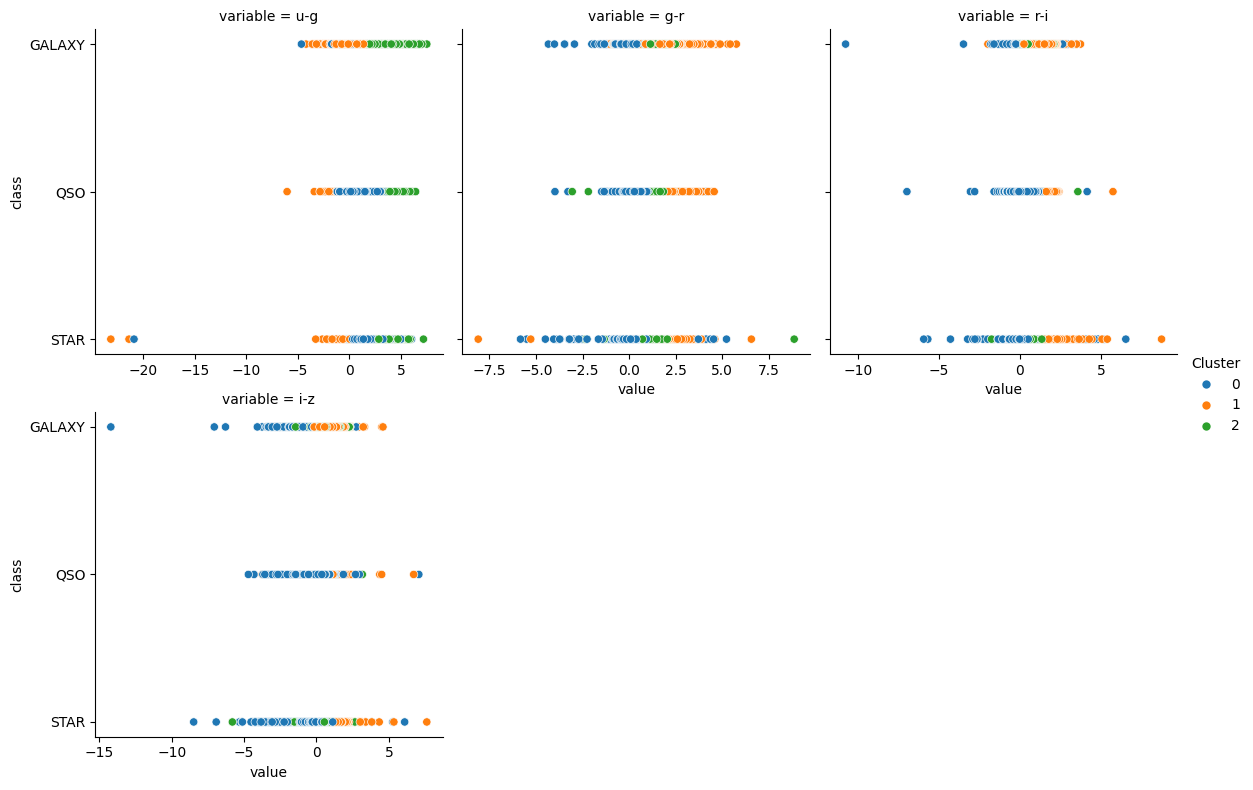

In [11]:
## Visualisasi
dfc = df.copy()
dfc["class"] = y

sns.relplot(
    x="value", y="class", hue="Cluster", col="variable",
    height=4, aspect=1, facet_kws={'sharex': False}, col_wrap=3,
    data=dfc.melt(
        value_vars=filter_col, id_vars=["class", "Cluster"],
    ),
)


## **TEST**